In [36]:
# compute topic modelling metrics

# for each doc: tanh (num of topic switches / num of sentence transitions)
# averaged across docs

In [37]:
import os
from tqdm import tqdm
from pathlib import Path
import pandas as pd
import json
import numpy as np

In [38]:
BERTOPIC_DATA_DIR = Path('/mimer/NOBACKUP/groups/naiss2025-22-1187/data/bertopic_inputs')
BERTOPIC_CACHE_DIR = Path('/mimer/NOBACKUP/groups/naiss2024-6-297/cache/bertopic_bootstrapped/full_training_10')
NR_TOPICS_LIST = list(range(5, 85, 5))  # [5, 10, 15, ..., 80]

# trained on balanced bootstrapped sets (720 stories each, 10 bootstraps)
# min_topic_size=10 (HDBSCAN default), nr_topics reduced from 80 down to 5 in steps of 5

In [39]:
def load_bertopic_metadata():
    metadata = pd.read_csv(BERTOPIC_DATA_DIR / 'all_stories_metadata.csv')
    with open(BERTOPIC_DATA_DIR / 'all_stories_texts.json', 'r') as f:
        stories = json.load(f)
    return metadata, stories

def create_sentence_to_story_mapping(stories, metadata):
    rows = []
    current_idx = 0
    for doc_id, doc in enumerate(stories):
        sentences = [sent.strip() for sent in doc.split('[SENT]') if sent.strip()]
        story_meta = metadata[metadata['story_index'] == doc_id].iloc[0]
        for pos, sent in enumerate(sentences):
            rows.append({
                'sentence_idx': current_idx, 'sentence_pos': pos,
                'n_sentences': len(sentences), 'story_index': doc_id,
                'story_id': story_meta['doc_key'],
                'model_type': story_meta['model_type'],
                'prompt_type': story_meta['prompt_type'],
                'seed': story_meta['seed'],
            })
            current_idx += 1
    return pd.DataFrame(rows)

def load_sentence_topics_for_config(bootstrap_idx, nr_topics):
    topic_path = BERTOPIC_CACHE_DIR / 'inference' / f'bootstrap_{bootstrap_idx:02d}' / f'topics_{nr_topics}' / 'sentence_topics.npy'
    if topic_path.exists():
        return np.load(topic_path)
    return None

In [40]:
def compute_topic_switch_rate(group):
    group = group.sort_values('sentence_pos')
    topics = group['topic'].values
    if len(topics) < 2:
        return np.nan
    n_changes = sum(1 for i in range(len(topics) - 1) if topics[i] != topics[i + 1])
    return np.tanh(n_changes / (len(topics) - 1))

In [41]:
def filter_by_seed_rules(df):
    original = df[(df['prompt_type'] == 'original') & (df['seed'] == 42)]
    large_ai = df[(df['prompt_type'] == 'large') & (df['model_type'] != 'human') & (df['seed'] == 42)]
    large_human = df[(df['prompt_type'] == 'large') & (df['model_type'] == 'human')]
    return pd.concat([original, large_ai, large_human], ignore_index=True)

def load_topic_switch_data():
    metadata, stories = load_bertopic_metadata()
    sentence_mapping = create_sentence_to_story_mapping(stories, metadata)

    inference_dir = BERTOPIC_CACHE_DIR / 'inference'

    available_configs = []
    for bootstrap_dir in sorted(os.listdir(inference_dir)):
        bootstrap_path = inference_dir / bootstrap_dir
        if not os.path.isdir(bootstrap_path):
            continue
        bootstrap_idx = int(bootstrap_dir.split('_')[1])
        for nr_topics in NR_TOPICS_LIST:
            topic_path = bootstrap_path / f'topics_{nr_topics}' / 'sentence_topics.npy'
            if topic_path.exists():
                available_configs.append((bootstrap_idx, nr_topics))

    all_topics_data = []
    for bootstrap_idx, nr_topics in tqdm(available_configs, desc="Loading topic configs"):
        topics = load_sentence_topics_for_config(bootstrap_idx, nr_topics)
        if topics is not None:
            df = sentence_mapping.copy()
            df['topic'] = topics
            df['bootstrap_idx'] = bootstrap_idx
            df['nr_topics'] = nr_topics
            all_topics_data.append(df)

    sentence_topics_df = pd.concat(all_topics_data, ignore_index=True)

    filtered_df = filter_by_seed_rules(sentence_topics_df)

    all_change_rates = filtered_df.groupby(
        ['model_type', 'prompt_type', 'seed', 'story_index', 'story_id', 'bootstrap_idx', 'nr_topics']
    ).apply(compute_topic_switch_rate).reset_index(name='topic_switch_rate')

    is_hl = (all_change_rates['model_type'] == 'human') & (all_change_rates['prompt_type'] == 'large')
    non_hl = all_change_rates[~is_hl][['model_type', 'prompt_type', 'story_id', 'bootstrap_idx', 'nr_topics', 'topic_switch_rate']]

    hl = all_change_rates[is_hl].groupby(['model_type', 'prompt_type', 'story_id', 'bootstrap_idx', 'nr_topics']).agg(
        topic_switch_rate=('topic_switch_rate', 'mean')
    ).reset_index()

    combined = pd.concat([non_hl, hl], ignore_index=True)

    story_avg = combined.groupby(['model_type', 'prompt_type', 'story_id']).agg(
        topic_switch_rate=('topic_switch_rate', 'mean')
    ).reset_index()

    story_lengths = filter_by_seed_rules(sentence_mapping).groupby(['model_type', 'prompt_type', 'story_id']).agg(
        n_sentences=('n_sentences', 'mean')
    ).reset_index()

    story_avg = story_avg.merge(
        story_lengths,
        on=['model_type', 'prompt_type', 'story_id'],
        how='left'
    )

    story_avg = story_avg.rename(columns={'model_type': 'model', 'prompt_type': 'prompt'})

    return story_avg

In [42]:
df_topic = load_topic_switch_data()
print(df_topic.head())

Loading topic configs: 100%|██████████| 160/160 [00:00<00:00, 723.75it/s]


      model prompt  story_id  topic_switch_rate  n_sentences
0  claude45  large       345           0.100533          5.0
1  claude45  large       515           0.241995          9.0
2  claude45  large       721           0.479396          5.0
3  claude45  large       723           0.403009          9.0
4  claude45  large       733           0.534631          6.0


In [43]:
# inspect one story's sentence rows and sentence texts

story_id_target = 10408
model_target = 'claude45'
prompt_target = 'large'
seed_target = 42

metadata, stories = load_bertopic_metadata()
sentence_mapping = create_sentence_to_story_mapping(stories, metadata)

story_rows = sentence_mapping[
    (pd.to_numeric(sentence_mapping['story_id'], errors='coerce') == story_id_target)
    & (sentence_mapping['model_type'] == model_target)
    & (sentence_mapping['prompt_type'] == prompt_target)
    & (sentence_mapping['seed'] == seed_target)
].sort_values('sentence_pos')

print('Sentence mapping rows:')
display(story_rows[['story_id', 'model_type', 'prompt_type', 'seed', 'story_index', 'sentence_pos', 'n_sentences']])

if len(story_rows) > 0:
    story_index = int(story_rows['story_index'].iloc[0])
    sentences = [s.strip() for s in stories[story_index].split('[SENT]') if s.strip()]
    print('\nSentence texts:')
    for i, sentence in enumerate(sentences):
        print(f'{i}: {sentence}')
else:
    print('\nNo rows found for that story/model/prompt/seed.')

Sentence mapping rows:


,story_id,model_type,prompt_type,seed,story_index,sentence_pos,n_sentences
41,10408,claude45,large,42,7,0,6
42,10408,claude45,large,42,7,1,6
43,10408,claude45,large,42,7,2,6
44,10408,claude45,large,42,7,3,6
45,10408,claude45,large,42,7,4,6
46,10408,claude45,large,42,7,5,6



Sentence texts:
0: Greta arrives at a waterfront park carrying a picnic basket and a colorful striped cooler , approaching Jake who stands near a grill with boats visible in the harbor behind them . The late afternoon sun casts a warm glow over the grassy area where other people are relaxing in the background .
1: Jake looks intently at Greta as they stand face to face in the park , his expression serious and focused . He wears a dark striped polo shirt , and the marina with its tall masts creates a picturesque backdrop for their conversation .
2: Greta smiles warmly while holding her phone , her blonde hair pulled back as she stands in the golden hour light . Her expression appears pleased and content as she continues her interaction with Jake near the waterfront .
3: The pair moves to a white gazebo structure where they set up their picnic , with the checkered tablecloth visible on the table between them . The setting sun filters through the trees , creating a romantic atmosphere as

In [44]:
topic_agg = (
    df_topic.groupby(['model', 'prompt'])
    .agg(
        n_sentences=('n_sentences', 'mean'),
        topic_switch_rate_mean=('topic_switch_rate', 'mean'),
        topic_switch_rate_std=('topic_switch_rate', 'std'),
        count=('topic_switch_rate', 'count')
    )
    .reset_index()
)

topic_agg

,model,prompt,n_sentences,topic_switch_rate_mean,topic_switch_rate_std,count
0,claude45,large,5.750000,0.261740,0.181005,60
1,claude45,original,5.666667,0.271575,0.200283,60
2,gpt4o,large,5.733333,0.314267,0.188339,60
3,gpt4o,original,5.600000,0.282886,0.182432,60
4,human,large,5.709056,0.334410,0.145253,60
5,human,original,5.800000,0.425266,0.144182,60
6,internvl3,large,6.116667,0.299822,0.214413,60
7,internvl3,original,5.950000,0.270864,0.178320,60
8,llama4scout,large,6.316667,0.351192,0.190516,60
9,llama4scout,original,5.650000,0.258780,0.169815,60


In [48]:
# n_sentences - num of sentences in a document, higher value -> longer story
# topic_switch_rate - proportion of adjacent sentence pairs where topic id changes

# topic switch rate - squashed between 0 and 1, tanh(num of topic switches / num of sentence transitions)
# values near 1: frequent topic shifts between neighboring sentences, less local topical continuity
# values near 0: infrequent topic shifts, neighboring sentences stay on similar topics (more local topical continuity)

In [46]:
# n_sentences per story and summary by model/prompt

n_sent_story = df_topic[['model', 'prompt', 'story_id', 'n_sentences']].copy()

n_sent_summary = (
    n_sent_story.groupby(['model', 'prompt'])['n_sentences']
    .agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    .reset_index()
)

print('n_sentences summary by model/prompt:')
n_sent_summary


n_sentences summary by model/prompt:


,model,prompt,count,mean,std,min,median,max
0,claude45,large,60,5.750000,1.216065,5.0,5.0,9.0
1,claude45,original,60,5.666667,1.188457,3.0,5.0,9.0
2,gpt4o,large,60,5.733333,1.191306,5.0,5.0,9.0
3,gpt4o,original,60,5.600000,0.994902,5.0,5.0,9.0
4,human,large,60,5.709056,1.166461,5.0,5.0,9.0
5,human,original,60,5.800000,1.362948,5.0,5.0,10.0
6,internvl3,large,60,6.116667,1.530389,2.0,6.0,11.0
7,internvl3,original,60,5.950000,1.111191,4.0,6.0,9.0
8,llama4scout,large,60,6.316667,1.672222,5.0,6.0,11.0
9,llama4scout,original,60,5.650000,1.232677,2.0,5.0,10.0


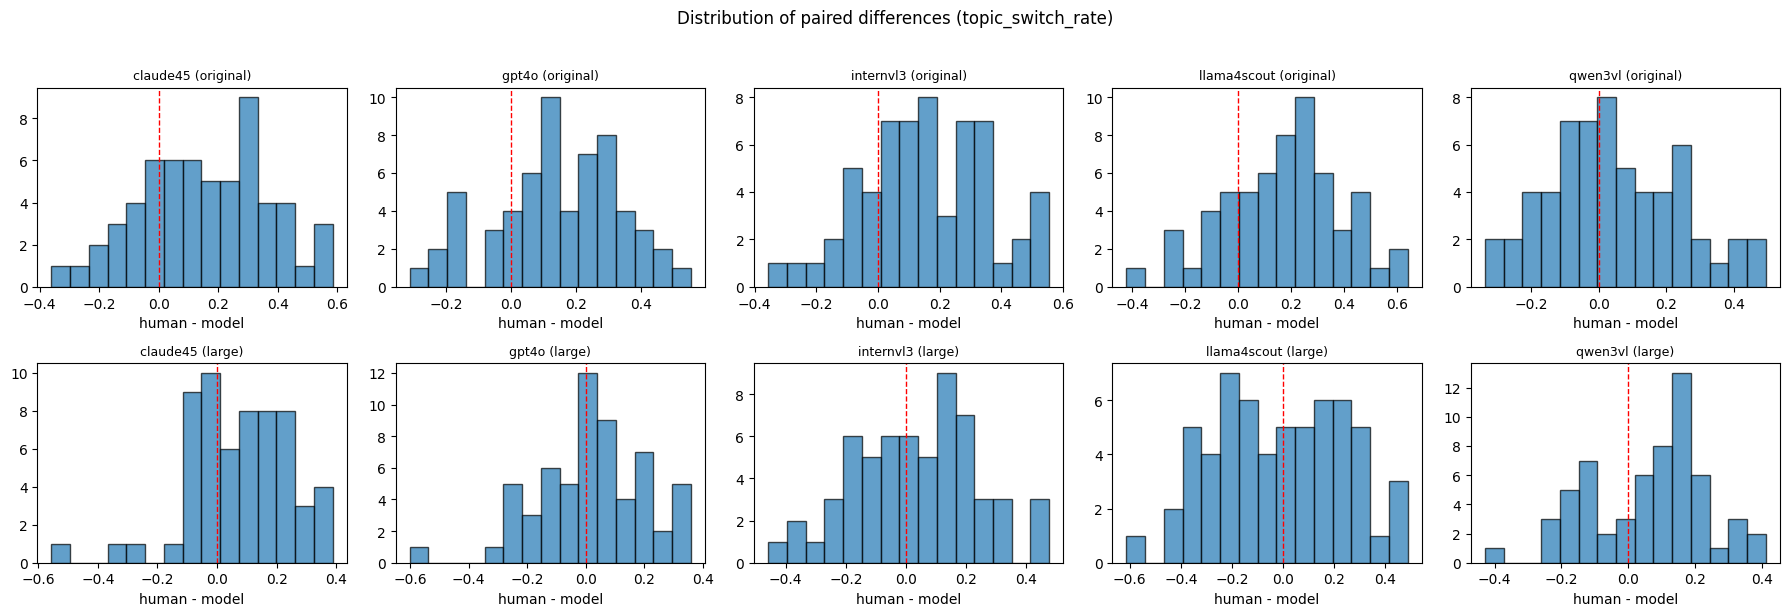

In [50]:
# visualising the distribution of topic_switch_rate differences between humans and each model
# check shape of paired differences before/alongside t-tests

import matplotlib.pyplot as plt

MODELS = ['human', 'claude45', 'gpt4o', 'internvl3', 'llama4scout', 'qwen3vl']
PROMPTS = ['original', 'large']

fig, axes = plt.subplots(len(PROMPTS), len(MODELS) - 1, figsize=(18, 6), squeeze=False)

for i, prompt in enumerate(PROMPTS):
    df_human = df_topic[(df_topic['model'] == 'human') & (df_topic['prompt'] == prompt)].set_index('story_id')
    col = 0
    for model in MODELS:
        if model == 'human':
            continue
        df_model = df_topic[(df_topic['model'] == model) & (df_topic['prompt'] == prompt)].set_index('story_id')
        common_ids = df_human.index.intersection(df_model.index)

        diffs = df_human.loc[common_ids, 'topic_switch_rate'].values - df_model.loc[common_ids, 'topic_switch_rate'].values

        ax = axes[i][col]
        ax.hist(diffs, bins=15, edgecolor='black', alpha=0.7)
        ax.axvline(0, color='red', linestyle='--', linewidth=1)
        ax.set_title(f"{model} ({prompt})", fontsize=9)
        ax.set_xlabel('human - model')
        col += 1

plt.suptitle('Distribution of paired differences (topic_switch_rate)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [51]:
from scipy.stats import ttest_rel

MODELS = ['human', 'claude45', 'gpt4o', 'internvl3', 'llama4scout', 'qwen3vl']
PROMPTS = ['original', 'large']

# Paired t-test per prompt, paired by story_id
# Models vs Humans
# do VLMs produce stories with different topic switch rates than humans?
# do VLMs shift topics between sentences differently than humans?

for prompt in PROMPTS:
    print(f"--- Prompt: {prompt} ---")
    df_human = df_topic[(df_topic['model'] == 'human') & (df_topic['prompt'] == prompt)].set_index('story_id')

    for model in MODELS:
        if model == 'human':
            continue
        df_model = df_topic[(df_topic['model'] == model) & (df_topic['prompt'] == prompt)].set_index('story_id')

        common_ids = df_human.index.intersection(df_model.index)
        if len(common_ids) == 0:
            print(f"  {model}: no common story_ids")
            continue

        human_vals = df_human.loc[common_ids, 'topic_switch_rate'].values
        model_vals = df_model.loc[common_ids, 'topic_switch_rate'].values

        stat, p = ttest_rel(human_vals, model_vals)
        direction = "model > human" if np.mean(model_vals) > np.mean(human_vals) else "model < human"
        print(f"  {model:15s}  t={stat:.3f}  p={p:.4f}  n={len(common_ids)}  ({direction})")
    print()

--- Prompt: original ---
  claude45         t=5.541  p=0.0000  n=60  (model < human)
  gpt4o            t=5.660  p=0.0000  n=60  (model < human)
  internvl3        t=5.764  p=0.0000  n=60  (model < human)
  llama4scout      t=5.763  p=0.0000  n=60  (model < human)
  qwen3vl          t=1.647  p=0.1049  n=60  (model < human)

--- Prompt: large ---
  claude45         t=3.261  p=0.0018  n=60  (model < human)
  gpt4o            t=0.843  p=0.4027  n=60  (model < human)
  internvl3        t=1.279  p=0.2058  n=60  (model < human)
  llama4scout      t=-0.511  p=0.6112  n=60  (model > human)
  qwen3vl          t=2.578  p=0.0124  n=60  (model < human)



In [ ]:
# in the original prompt, 4/5 models switch topics significantly less than humans, and humans have higher switch rates than models
# qwen is an exception, close to humans
# in the large prompt, the gap narrows, human switch rate drops, 3/5 models are not significantly different from humans anymore
# llama4 exceeds even, so, it's an outlier?
# possible explanation: in the large prompt, humans have more space to focus on one topic as now they can expand on the topic (but ofc this also can be an artefact of the topic model we are using, because it's just not able to capture topic shifts in the large prompt)

In [52]:
# Paired t-test per model, paired by story_id
# Original vs Large prompt
# do VLMs differ in their topic switch rate across prompts?

for model in MODELS:
    df_orig = df_topic[(df_topic['model'] == model) & (df_topic['prompt'] == 'original')].set_index('story_id')
    df_large = df_topic[(df_topic['model'] == model) & (df_topic['prompt'] == 'large')].set_index('story_id')

    common_ids = df_orig.index.intersection(df_large.index)
    if len(common_ids) == 0:
        print(f"  {model}: no common story_ids")
        continue

    orig_vals = df_orig.loc[common_ids, 'topic_switch_rate'].values
    large_vals = df_large.loc[common_ids, 'topic_switch_rate'].values

    stat, p = ttest_rel(orig_vals, large_vals)
    direction = "large > original" if np.mean(large_vals) > np.mean(orig_vals) else "large < original"
    print(f"  {model:15s}  t={stat:.3f}  p={p:.4f}  n={len(common_ids)}  ({direction})")

  human            t=4.342  p=0.0001  n=60  (large < original)
  claude45         t=0.803  p=0.4255  n=60  (large < original)
  gpt4o            t=-1.729  p=0.0890  n=60  (large > original)
  internvl3        t=-1.429  p=0.1584  n=60  (large > original)
  llama4scout      t=-2.853  p=0.0060  n=60  (large > original)
  qwen3vl          t=5.189  p=0.0000  n=60  (large < original)


In [ ]:
# humans and qwen decrease topic switch rate with the large prompt
# llama is an outlier, it increases the rate
# other models don't show significant changes

In [54]:
topicdata_path = Path('./analysis_data/topic_modelling/')
topicdata_path.mkdir(parents=True, exist_ok=True)

df_topic.to_csv(topicdata_path / 'topic_switch_metrics.csv', index=False)
topic_agg.to_csv(topicdata_path / 'topic_switch_metrics_agg.csv', index=False)

print(f"Saved to {topicdata_path.resolve()}")
print(f"  topic_switch_metrics.csv     ({len(df_topic)} rows)")
print(f"  topic_switch_metrics_agg.csv ({len(topic_agg)} rows)")

Saved to /mimer/NOBACKUP/groups/naiss2025-22-1187/coherence-driven-humans/analysis/analysis_data/topic_modelling
  topic_switch_metrics.csv     (720 rows)
  topic_switch_metrics_agg.csv (12 rows)
